<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/ANALISE_ESPACIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Espacial Utilizando o Python

In [1]:
# BIBLIOTECAS
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium
import mapclassify
import branca.colormap as cm
import os
import numpy as np

# **Carregar os dados**

Google Drive

     ↓

gdown

     ↓

Mapas_trabalho.zip

     ↓

extrair ZIP

     ↓

distritos_sp.gpkg + pontos_sp.shp

     ↓

GeoPandas

In [2]:
import gdown

file_id = "1KZlCn6dMxR9KGlSyWtDtF4v4XLvFW84b"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Mapas_trabalho.zip",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1KZlCn6dMxR9KGlSyWtDtF4v4XLvFW84b
To: /content/Mapas_trabalho.zip
100%|██████████| 1.44M/1.44M [00:00<00:00, 142MB/s]


'Mapas_trabalho.zip'

In [3]:
import zipfile

with zipfile.ZipFile("Mapas_trabalho.zip", "r") as zip_ref:
    zip_ref.extractall("mapas")

In [4]:
localidade = gpd.read_file("mapas/distritos_sp.gpkg")
enderecos = gpd.read_file("mapas/pontos_sp.shp")

print(localidade.crs)
print(enderecos.crs)

EPSG:4674
EPSG:3857


# **Visualização dos mapas**

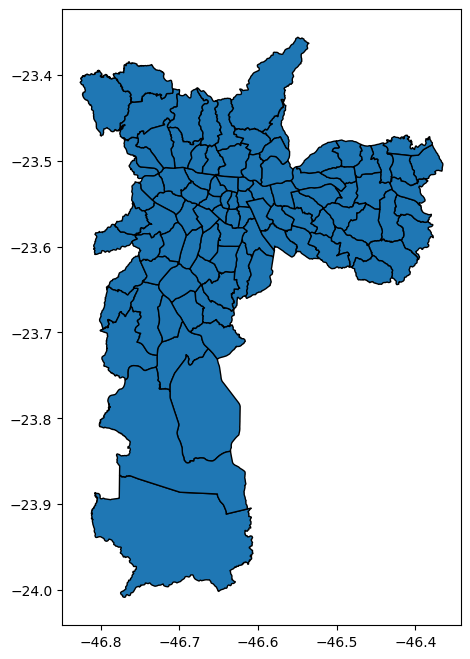

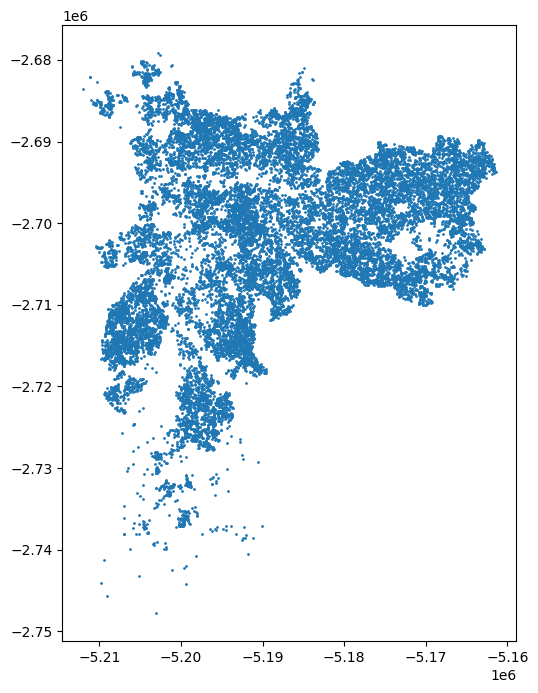

In [5]:
# Visualizações iniciais

localidade.plot(edgecolor="black", figsize=(8,8)) # Distritos de São Paulo
plt.show()

enderecos.plot(markersize=1, figsize=(8,8)) # Pontos localizados em São Paulo - residências e pontos comerciais
plt.show()

EPSG:3857


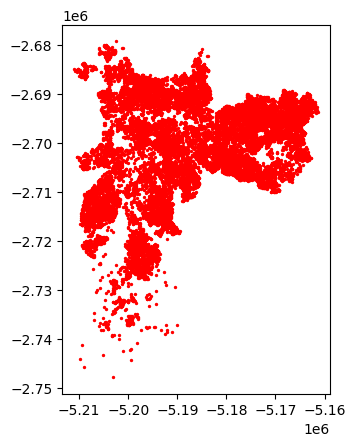

In [6]:
# Filtrar domicílios (apenas pontos que são residências)

domicilios = enderecos[enderecos["COD_ESP"] == 1].copy()

print(domicilios.crs)

domicilios.plot(color="red", markersize=2)
plt.show()

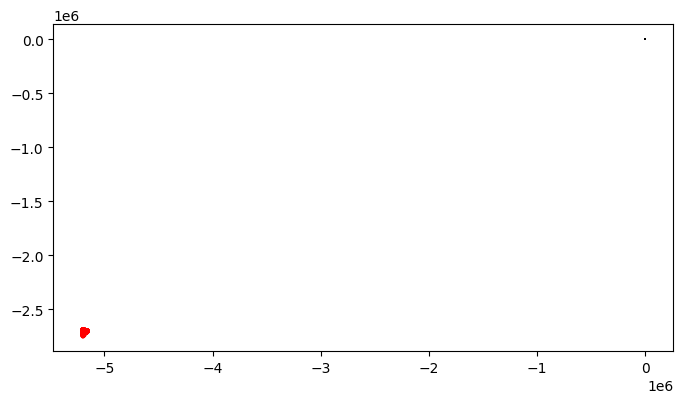

In [7]:
# Sobreposição - Pontos e Polígonos

ax = localidade.plot(facecolor="white",
                     edgecolor="black",
                     figsize=(8,8))

domicilios.plot(ax=ax,
                color="red",
                markersize=2)

plt.show()

In [8]:
# Mudança de projeção - O resultados acima não está adequado

localidade3857 = localidade.to_crs(3857)
domicilios3857 = domicilios.to_crs(3857)

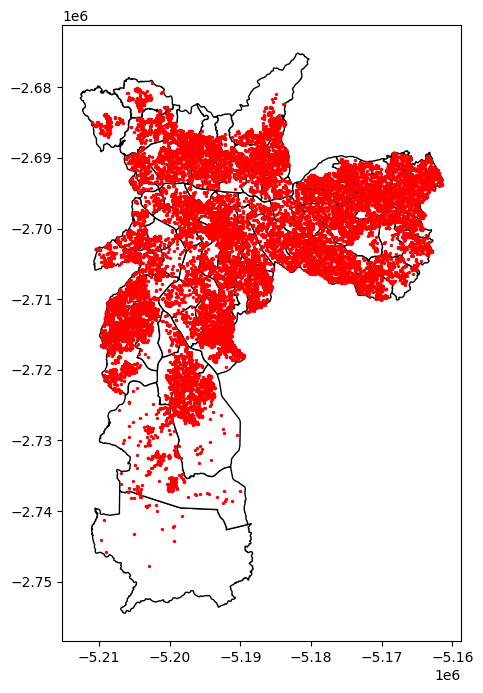

In [9]:
# Sobreposição - Pontos e Polígonos

ax = localidade3857.plot(facecolor="white",
                     edgecolor="black",
                     figsize=(8,8))

domicilios3857.plot(ax=ax,
                color="red",
                markersize=2)

plt.show()

In [10]:
# Contagem de domicílios por distrito

localidade3857 = localidade.to_crs(3857)
domicilios3857 = domicilios.to_crs(3857)

join = gpd.sjoin(
    domicilios3857,
    localidade3857,
    predicate="within",
    how="left")

contagem = join.groupby(join.index_right).size()

localidade3857["qtd_domicilios"] = (
    contagem.reindex(localidade3857.index)
    .fillna(0)
    .astype(int))

print(localidade3857["qtd_domicilios"].sum())
print(len(domicilios3857))

17094
17100


In [11]:
# Domicílios fora dos distritos

fora = join[join["index_right"].isna()].copy()

print(len(fora))

6
